Data shape: (50000, 32, 32, 3)


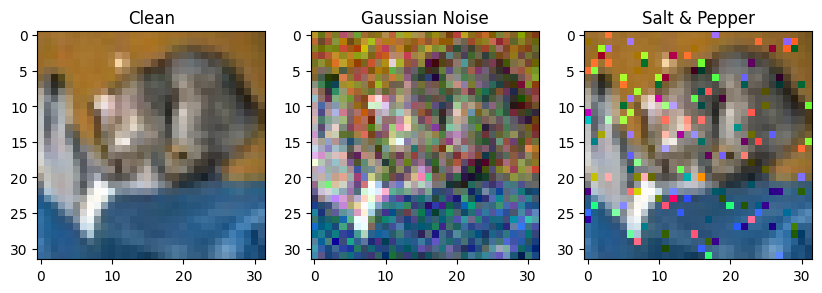

In [7]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt

# Load data
(x_train, _), (x_test, _) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Data shape:", x_train.shape)

# Function to add noise
def add_gaussian_noise(images, sigma=0.1):
    noise = np.random.normal(0, sigma, images.shape)
    noisy = np.clip(images + noise, 0.0, 1.0)
    return noisy

def add_salt_pepper_noise(images, amount=0.05):
    noisy = images.copy()
    salt = np.random.random(images.shape) < amount/2
    pepper = np.random.random(images.shape) < amount/2
    noisy[salt] = 1.0
    noisy[pepper] = 0.0
    return noisy

# Create noisy versions
x_train_gauss = add_gaussian_noise(x_train, sigma=0.1)
x_test_gauss = add_gaussian_noise(x_test, sigma=0.1)

x_train_sp = add_salt_pepper_noise(x_train, amount=0.05)
x_test_sp = add_salt_pepper_noise(x_test, amount=0.05)

# Visualization example
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.imshow(x_test[0]); plt.title('Clean')
plt.subplot(1,3,2); plt.imshow(x_test_gauss[0]); plt.title('Gaussian Noise')
plt.subplot(1,3,3); plt.imshow(x_test_sp[0]); plt.title('Salt & Pepper')
plt.show()

In [8]:
def build_dae():
    input_img = tf.keras.Input(shape=(32, 32, 3))
    
    # Encoder
    x = tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same')(input_img)
    x = tf.keras.layers.MaxPooling2D((2,2), padding='same')(x)
    x = tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    encoded = tf.keras.layers.MaxPooling2D((2,2), padding='same')(x)
    
    # Decoder (using Transposed Convolution)
    x = tf.keras.layers.Conv2DTranspose(128, (3,3), activation='relu', padding='same')(encoded)
    x = tf.keras.layers.UpSampling2D((2,2))(x)
    x = tf.keras.layers.Conv2DTranspose(64, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.UpSampling2D((2,2))(x)
    decoded = tf.keras.layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)
    
    autoencoder = tf.keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

dae = build_dae()
dae.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 8, 8, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_8 (UpSampling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 16, 16, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_9 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 298,755 (1.14 MB)

 Trainable params: 298,755 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train on Gaussian noise
print("Training DAE on Gaussian Noise...")
dae_gauss = build_dae()
dae_gauss.fit(x_train_gauss, x_train,
              epochs=10,
              batch_size=64,
              validation_data=(x_test_gauss, x_test),
              verbose=1)

# Train on Salt & Pepper noise
print("Training DAE on Salt & Pepper Noise...")
dae_sp = build_dae()
dae_sp.fit(x_train_sp, x_train,
           epochs=10,
           batch_size=64,
           validation_data=(x_test_sp, x_test),
           verbose=1)

Training DAE on Gaussian Noise...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 239s 304ms/step - loss: 0.0074 - val_loss: 0.0046
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 237s 303ms/step - loss: 0.0041 - val_loss: 0.0036
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 246s 314ms/step - loss: 0.0034 - val_loss: 0.0032
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 249s 318ms/step - loss: 0.0031 - val_loss: 0.0029
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 242s 309ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 250s 319ms/step - loss: 0.0027 - val_loss: 0.0026
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 249s 318ms/step - loss: 0.0026 - val_loss: 0.0025
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 253s 323ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 256s 328ms/step - loss: 0.0024 - val_loss: 0.0025
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 251s 321ms/step - loss: 0.0024 - val_loss: 0.0024
Training DAE on Salt & Pepper Noise...
Epoch 1/10
782/782 ━━━━━━━

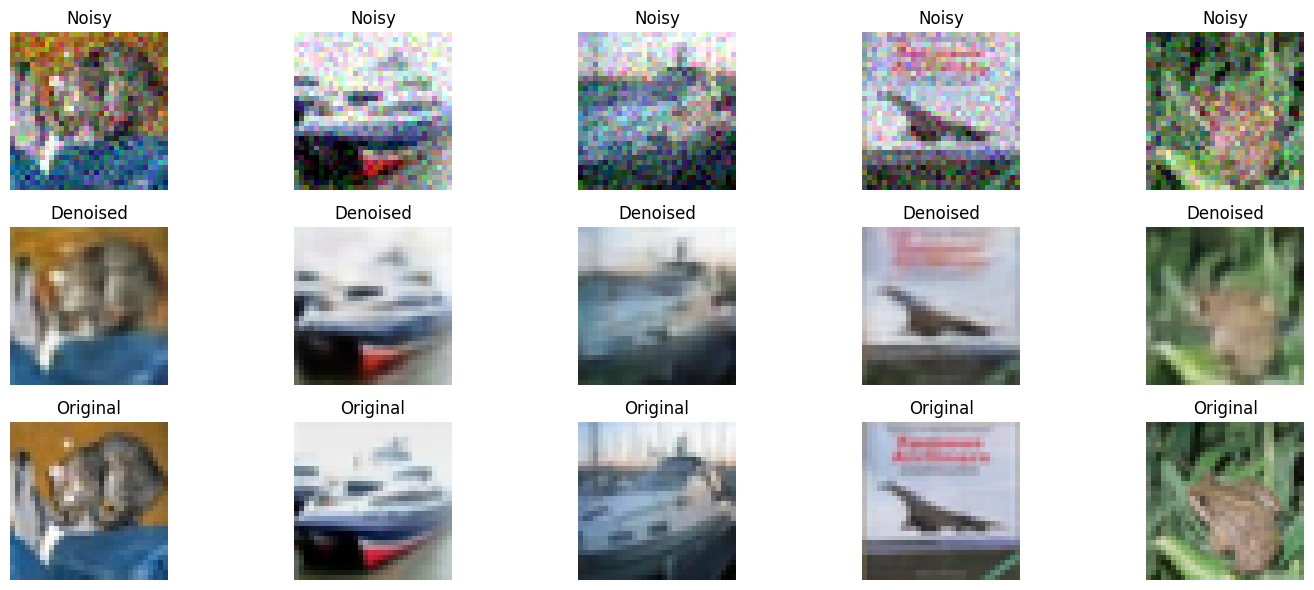

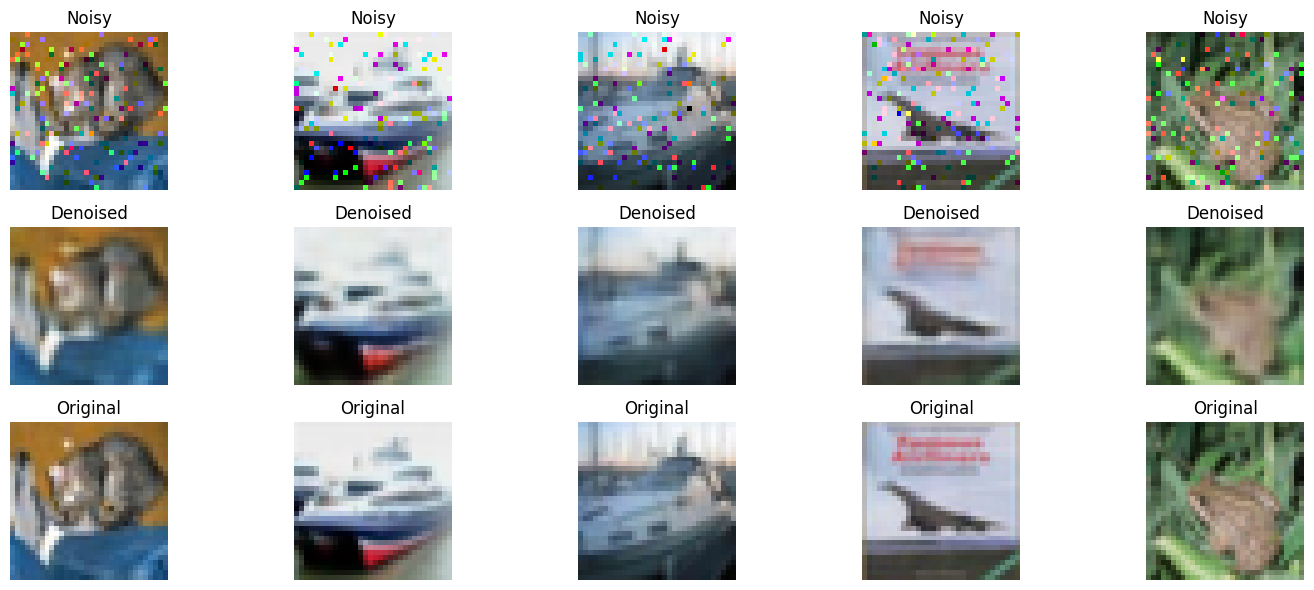

In [11]:
def plot_denoising_results(model, noisy_images, clean_images, n=5):
    plt.figure(figsize=(15, 6))
    for i in range(n):
        # Noisy
        plt.subplot(3, n, i+1)
        plt.imshow(noisy_images[i])
        plt.title('Noisy')
        plt.axis('off')
        
        # Reconstructed
        pred = model.predict(np.expand_dims(noisy_images[i], 0), verbose=0)[0]
        plt.subplot(3, n, i+1+n)
        plt.imshow(pred)
        plt.title('Denoised')
        plt.axis('off')
        
        # Original
        plt.subplot(3, n, i+1+2*n)
        plt.imshow(clean_images[i])
        plt.title('Original')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Example for Gaussian
plot_denoising_results(dae_gauss, x_test_gauss[:5], x_test[:5])
# Example for Salt and Pepper
plot_denoising_results(dae_sp, x_test_sp[:5], x_test[:5])